# Learner Trajectory Analysis

This notebook is the **external testing tool** for the Moodle trajectory extraction plugin.

It calls the plugin's REST API to fetch raw learner navigation data and performs basic
Educational Data Mining (EDM) analysis:

1. Fetch trajectory events from Moodle via the web service API
2. Analyse **time spent** per activity
3. Discover the most common **navigation sequences** (learner paths)
4. Produce a **per-user summary**

---
**Setup:** Install dependencies once by running the cell below, then paste your Moodle token.

In [1]:
# Run this cell once to install required libraries
# !pip install requests pandas matplotlib seaborn

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

# ── Configuration ─────────────────────────────────────────────────────────────
MOODLE_URL = "http://localhost:8081"
TOKEN      = "39d6456f4b9de562393d46a058a923d6"   # Site admin → Web services → Manage tokens
# ──────────────────────────────────────────────────────────────────────────────

## 1. Fetch Trajectory Data from Moodle

The plugin exposes a REST endpoint. We authenticate with the token and optionally
filter by `courseid`, `userid`, or `since` (Unix timestamp).

In [3]:
def get_trajectories(courseid=0, userid=0, since=0):
    """Call the Moodle web service and return trajectory events as a list of dicts."""
    params = {
        "wstoken":            TOKEN,
        "wsfunction":         "local_nextclicks_get_trajectories",
        "moodlewsrestformat": "json",
        "courseid":           courseid,
        "userid":             userid,
        "since":              since,
    }
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise Exception(f"Moodle API error: {data.get('message', data)}")
    return data

raw = get_trajectories()   # fetch everything; add filters as needed
print(f"Fetched {len(raw)} trajectory events")
raw[:3]

Fetched 4 trajectory events


[{'id': 1,
  'userid': 2,
  'courseid': 3,
  'itemtype': 'course',
  'itemid': 3,
  'timecreated': 1772139887,
  'timespent': 116},
 {'id': 2,
  'userid': 2,
  'courseid': 3,
  'itemtype': 'course',
  'itemid': 3,
  'timecreated': 1772140003,
  'timespent': 23},
 {'id': 3,
  'userid': 2,
  'courseid': 3,
  'itemtype': 'cm',
  'itemid': 2,
  'timecreated': 1772140026,
  'timespent': 0}]

In [4]:
df = pd.DataFrame(raw)

# Convert Unix timestamp to readable datetime
df["datetime"] = pd.to_datetime(df["timecreated"], unit="s")

# Human-readable label for each visited item, e.g. "cm:3" or "course:2"
df["label"] = df["itemtype"] + ":" + df["itemid"].astype(str)

df = df.sort_values(["userid", "timecreated"]).reset_index(drop=True)
df.head(10)

,id,userid,courseid,itemtype,itemid,timecreated,timespent,datetime,label
0,1,2,3,course,3,1772139887,116,2026-02-26 21:04:47,course:3
1,2,2,3,course,3,1772140003,23,2026-02-26 21:06:43,course:3
2,3,2,3,cm,2,1772140026,0,2026-02-26 21:07:06,cm:2
3,4,2,2,course,2,1772140060,0,2026-02-26 21:07:40,course:2


## 2. Time Spent per Activity

`timespent` (seconds) is calculated server-side by the plugin: it is the gap between
this event and the next event for the same user in the same course.
A value of `0` means the event was the last one in the session (unknown duration).

In [5]:
# Only include events where we know the time spent
timed = df[df["timespent"] > 0].copy()

avg_time = (
    timed.groupby("label")["timespent"]
    .agg(visits="count", avg_seconds="mean", total_seconds="sum")
    .sort_values("avg_seconds", ascending=False)
    .reset_index()
)
avg_time["avg_minutes"] = (avg_time["avg_seconds"] / 60).round(2)
avg_time

,label,visits,avg_seconds,total_seconds,avg_minutes
0,course:3,2,69.5,139,1.16


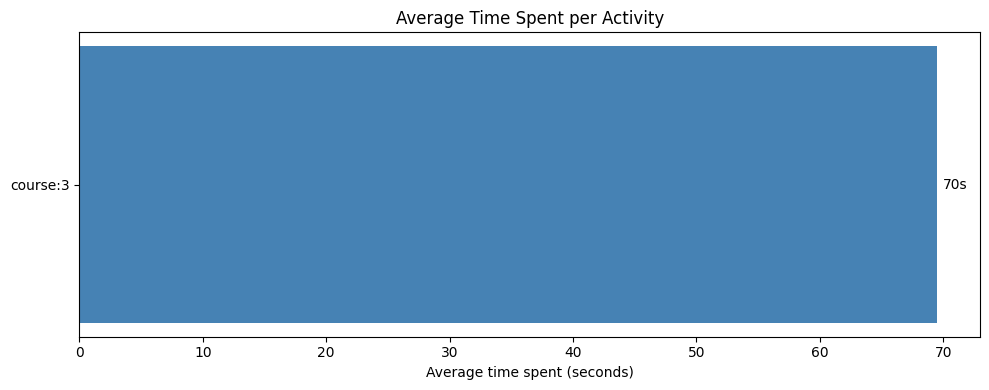

In [6]:
fig, ax = plt.subplots(figsize=(10, max(4, len(avg_time) * 0.5)))
bars = ax.barh(avg_time["label"], avg_time["avg_seconds"], color="steelblue")
ax.bar_label(bars, labels=[f"{v:.0f}s" for v in avg_time["avg_seconds"]], padding=4)
ax.set_xlabel("Average time spent (seconds)")
ax.set_title("Average Time Spent per Activity")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Navigation Sequences (Learner Paths)

We reconstruct each learner's full navigation path and find the most common
two-step transitions — this is the core of clickstream-based EDM.

In [7]:
# Build the ordered sequence of pages visited per user
sequences = (
    df.sort_values(["userid", "timecreated"])
    .groupby("userid")["label"]
    .apply(list)
    .reset_index()
)
sequences.columns = ["userid", "path"]
sequences["path_str"] = sequences["path"].apply(lambda p: " → ".join(p))
sequences[["userid", "path_str"]]

,userid,path_str
0,2,course:3 → course:3 → cm:2 → course:2


In [8]:
# Extract all two-step transitions (A → B) across all users
def bigrams(seq):
    return [(seq[i], seq[i + 1]) for i in range(len(seq) - 1)]

all_transitions = []
for path in sequences["path"]:
    all_transitions.extend(bigrams(path))

top_transitions = pd.DataFrame(
    Counter(all_transitions).most_common(10),
    columns=["transition", "count"]
)
top_transitions["transition"] = top_transitions["transition"].apply(
    lambda t: f"{t[0]}  →  {t[1]}"
)
top_transitions

,transition,count
0,course:3 → course:3,1
1,course:3 → cm:2,1
2,cm:2 → course:2,1


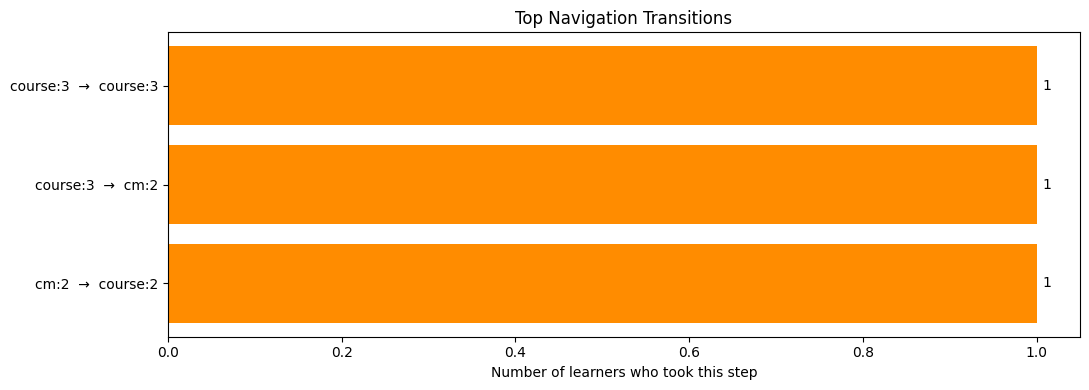

In [9]:
fig, ax = plt.subplots(figsize=(11, max(4, len(top_transitions) * 0.55)))
bars = ax.barh(top_transitions["transition"], top_transitions["count"], color="darkorange")
ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of learners who took this step")
ax.set_title("Top Navigation Transitions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Per-User Summary

A high-level view of each learner's engagement: how many pages they visited,
how long they spent in total, and how many unique activities they explored.

In [10]:
summary = (
    df.groupby("userid")
    .agg(
        total_events       = ("id",          "count"),
        unique_activities  = ("label",        "nunique"),
        total_time_seconds = ("timespent",    "sum"),
        first_seen         = ("datetime",     "min"),
        last_seen          = ("datetime",     "max"),
    )
    .reset_index()
)
summary["total_time_minutes"]    = (summary["total_time_seconds"] / 60).round(2)
summary["session_span_minutes"]  = (
    (summary["last_seen"] - summary["first_seen"]).dt.total_seconds() / 60
).round(2)
summary

,userid,total_events,unique_activities,total_time_seconds,first_seen,last_seen,total_time_minutes,session_span_minutes
0,2,4,3,139,2026-02-26 21:04:47,2026-02-26 21:07:40,2.32,2.88
